# Timerseries Analysis

In [61]:
!pip install numpy pandas scikit-learn matplotlib tqdm stumpy tslearn

In [62]:
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tslearn.shapelets import LearningShapelets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import glob
from sklearn.cluster import KMeans
from typing import Optional, List, Dict
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from tqdm import tqdm
import stumpy

## Load Audio and Extract Features

Load each file, trim, normalize amplitude, beattrack and then extract features.

In [63]:
def extract_beat_sync_features(
    mp3_path: str,
    sr: int = 22050,
    trim_db: int = 25,
    hop_length: int = 512,
    n_mfcc: int = 13,
) -> dict:
    y, sr = librosa.load(mp3_path, sr=sr, mono=True)
    y, _ = librosa.effects.trim(y, top_db=trim_db)

    # normalize peak amplitude
    peak = np.max(np.abs(y)) + 1e-9
    y = y / peak

    duration = librosa.get_duration(y=y, sr=sr)

    # beat tracking
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    tempo, beat_frames = librosa.beat.beat_track(
        onset_envelope=onset_env, sr=sr, hop_length=hop_length
    )
    if len(beat_frames) < 2:
        # fallback: if beat tracking fails, treat it like one "beat" at start
        beat_frames = np.array([0], dtype=int)

    beat_times = librosa.frames_to_time(
        beat_frames, sr=sr, hop_length=hop_length
    )

    # frame-level features
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length
    )  # (n_mfcc, n_frames)

    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, hop_length=hop_length
    )  # (12, n_frames)

    # use the same onset envelope as a 1D rhythmic/dynamic feature
    onset = onset_env.reshape(1, -1)  # (1, n_frames)

    # beat-synchronous aggregation (median is robust)
    mfcc_bs = librosa.util.sync(mfcc, beat_frames, aggregate=np.median).T
    chroma_bs = librosa.util.sync(chroma, beat_frames, aggregate=np.median).T
    onset_bs = librosa.util.sync(onset, beat_frames, aggregate=np.median).T

    return {
        "mfcc_bs": mfcc_bs,
        "chroma_bs": chroma_bs,
        "onset_bs": onset_bs,
        "tempo": float(tempo),
        "beat_times": beat_times,
        "duration": float(duration),
    }

audio_features = []
files = sorted(glob.glob("./fedez_fibra/*.mp3"))
for mp3_path in tqdm(files):
    out = extract_beat_sync_features(mp3_path)
    out["artist"] = mp3_path.split(" ")[0].split("/")[-1]
    audio_features.append(out)

pd.DataFrame(audio_features).head()

  0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipython-input-500636780.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "tempo": float(tempo),
100%|██████████| 40/40 [02:12<00:00,  3.31s/it]


,mfcc_bs,chroma_bs,onset_bs,tempo,beat_times,duration,artist
0,"[[-350.31302, 91.51345, 13.632147, 17.825752, ...","[[0.43872678, 0.3837296, 0.24992841, 0.4454901...","[[0.3700192], [0.50319743], [0.6125635], [0.62...",89.102909,"[1.0913378684807256, 1.787936507936508, 2.4613...",119.675646,ART07024718
1,"[[-242.33176, 70.255615, 21.659698, -4.7515206...","[[0.22477446, 0.4121868, 0.20322362, 0.0439523...","[[1.5244019], [1.0129039], [1.344775], [1.2036...",123.046875,"[2.507755102040816, 2.995374149659864, 3.50621...",122.694240,ART07024718
2,"[[-59.30336, 49.993156, 17.600971, 12.012688, ...","[[0.33985007, 0.34022716, 0.36318257, 0.873989...","[[0.0], [0.8429301], [0.96645844], [1.4517418]...",123.046875,"[0.06965986394557823, 0.5572789115646258, 1.04...",185.527438,ART07024718
3,"[[-52.306362, 85.76689, -3.7307644, 64.84314, ...","[[1.0, 0.825508, 0.74452335, 0.62281924, 0.483...","[[0.0], [0.31376687], [0.28439698], [0.3359669...",92.285156,"[0.06965986394557823, 0.8591383219954648, 1.50...",181.998005,ART07024718
4,"[[-142.6217, 22.849405, -68.81631, 13.575655, ...","[[0.34224695, 0.34331128, 0.4847735, 0.8262353...","[[0.0], [0.53303945], [0.5429715], [0.2990343]...",129.199219,"[0.06965986394557823, 0.5340589569160997, 0.99...",196.742676,ART07024718


## Feature Aggregation for Clustering

We aggregate the features extracted in the previous step into a single fixed-length feature vector per song. This allows for clustering the songs without the need to use DTW or subsequences.

Selected aggregated features per song:

- Basic track/tempo descriptors
  - duration: total length in seconds
  - tempo: estimated BPM from beat tracking
  - n_beats: number of detected beats (rough proxy for song length / beat density)

- MFCC statistics (timbre / production / "color")
  - mfcc_mean_*: mean of each MFCC coefficient across beats
  - mfcc_std_*: standard deviation of each MFCC coefficient across beats
  - mfcc_var_mean: average variance across MFCC coefficients (overall timbre variability)

- Chroma statistics (tonality / harmonic content distribution)
  - chroma_mean_*: average energy for each pitch class (12 dimensions)
  - chroma_std_*: variability of each pitch class across beats
  - chroma_entropy: entropy of the normalized chroma mean vector
    (higher = more evenly spread pitch classes; lower = more dominated by a few)
  - chroma_max_frac: fraction of energy in the most dominant pitch class

- Onset strength statistics (rhythmic density / dynamic “punch”)
  - onset_mean: average and variability of beat-synchronous onset strength
  - onset_std: average and variability of beat-synchronous onset strength
  - onset_p95: 95th percentile (captures strong accent peaks)
  - onset_peakiness: ratio p95 / mean (how “spiky” the accents are)
  - onset_diff_mean: mean / 95th percentile of absolute beat-to-beat
    changes in onset strength (proxy for structural/dynamic changes)

In [64]:
def summarize_song_features(out: dict) -> dict:
    mfcc = out["mfcc_bs"]          # (T, n_mfcc)
    chroma = out["chroma_bs"]      # (T, 12)
    onset = out["onset_bs"][:, 0]  # (T,)

    eps = 1e-9

    agg = {}
    agg["artist"] = out["artist"]
    agg["tempo"] = out["tempo"]
    agg["duration"] = out["duration"]
    agg["n_beats"] = float(mfcc.shape[0])

    # mean and std per coefficient
    mfcc_mean = mfcc.mean(axis=0)
    mfcc_std = mfcc.std(axis=0)
    for i, v in enumerate(mfcc_mean, start=1):
        agg[f"mfcc_mean_{i:02d}"] = float(v)
    for i, v in enumerate(mfcc_std, start=1):
        agg[f"mfcc_std_{i:02d}"] = float(v)

    agg["mfcc_var_mean"] = float(np.mean(mfcc_std**2))

    chroma_mean = chroma.mean(axis=0)
    chroma_std = chroma.std(axis=0)

    # normalize chroma_mean to a distribution for entropy-like features
    p = chroma_mean / (chroma_mean.sum() + eps)

    for k, v in enumerate(chroma_mean):
        agg[f"chroma_mean_{k:02d}"] = float(v)
    for k, v in enumerate(chroma_std):
        agg[f"chroma_std_{k:02d}"] = float(v)

    agg["chroma_entropy"] = float(-(p * np.log(p + eps)).sum())
    agg["chroma_max_frac"] = float(p.max())  # dominance of one pitch class

    # Onset strength summary stats (rhythm / dynamics proxy)
    agg["onset_mean"] = float(onset.mean())
    agg["onset_std"] = float(onset.std())
    agg["onset_p95"] = float(np.percentile(onset, 95))
    agg["onset_peakiness"] = float(
        np.percentile(onset, 95) / (onset.mean() + eps)
    )

    # simple "section change" proxy: how often onset changes sharply beat-to-beat
    diff = np.abs(np.diff(onset))
    agg["onset_diff_mean"] = float(diff.mean()) if diff.size else 0.0
    agg["onset_diff_p95"] = float(np.percentile(diff, 95)) if diff.size else 0.0

    return agg


# extract aggregated metadata features for all songs
agg_rows = []
for out in audio_features:
    agg_rows.append(summarize_song_features(out))

df = pd.DataFrame(agg_rows)
og_df = df.copy(deep=True)
df = df.drop(columns=["artist"])

print(df.shape)
pd.set_option('display.max_columns', None)
df.head()

(40, 62)


,tempo,duration,n_beats,mfcc_mean_01,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_05,mfcc_mean_06,mfcc_mean_07,mfcc_mean_08,mfcc_mean_09,mfcc_mean_10,mfcc_mean_11,mfcc_mean_12,mfcc_mean_13,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_04,mfcc_std_05,mfcc_std_06,mfcc_std_07,mfcc_std_08,mfcc_std_09,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_02,chroma_mean_03,chroma_mean_04,chroma_mean_05,chroma_mean_06,chroma_mean_07,chroma_mean_08,chroma_mean_09,chroma_mean_10,chroma_mean_11,chroma_std_00,chroma_std_01,chroma_std_02,chroma_std_03,chroma_std_04,chroma_std_05,chroma_std_06,chroma_std_07,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_entropy,chroma_max_frac,onset_mean,onset_std,onset_p95,onset_peakiness,onset_diff_mean,onset_diff_p95
0,89.102909,119.675646,175.0,-158.168900,103.729576,3.666086,38.286690,6.462377,17.200384,-9.020932,8.186444,-15.491856,12.498502,-3.951240,-0.101257,-5.834316,106.947578,20.744963,15.191677,13.263685,10.978548,8.240154,9.611194,7.740863,9.499741,7.823032,5.332959,6.590291,5.685448,990.093506,0.222746,0.205942,0.216175,0.316212,0.504544,0.347253,0.316143,0.431757,0.379747,0.411046,0.306597,0.272804,0.149091,0.148490,0.129447,0.162394,0.253724,0.173641,0.168443,0.240155,0.171074,0.245911,0.137189,0.132367,2.448570,0.128351,1.026717,0.360128,1.549208,1.508895,0.209277,0.556716
1,123.046875,122.694240,243.0,-51.307949,94.274467,-10.893712,10.078119,5.699718,5.601114,-5.013778,3.204492,-5.247590,1.615436,-2.062113,1.850235,1.923126,42.064415,18.266649,14.100110,13.038759,13.833110,9.725368,8.494978,8.429314,6.369574,6.134577,5.792819,5.792888,6.600730,237.688614,0.388347,0.472805,0.524635,0.471819,0.435879,0.364299,0.319499,0.312314,0.373174,0.363408,0.398953,0.410998,0.142900,0.192324,0.205464,0.179194,0.179943,0.163741,0.153971,0.150786,0.196918,0.181945,0.191594,0.165256,2.473500,0.108482,1.307706,0.356755,1.850941,1.415410,0.290918,0.727804
2,123.046875,185.527438,364.0,-63.896324,82.414978,-1.491515,8.552964,6.751056,5.475074,-5.372694,2.871174,-5.015740,2.478053,-4.113449,1.432435,-3.011875,95.649117,24.659382,22.954193,13.523681,15.784090,11.420725,9.411446,11.458076,8.550924,7.960243,7.538289,7.624221,9.029694,876.848572,0.404990,0.417858,0.417417,0.429843,0.455879,0.386755,0.320775,0.366050,0.387638,0.457095,0.441335,0.409223,0.196240,0.200238,0.206617,0.205386,0.215845,0.181878,0.158671,0.181558,0.191228,0.258999,0.230848,0.194442,2.480602,0.093383,1.067506,0.340703,1.563847,1.464953,0.230953,0.711033
3,92.285156,181.998005,251.0,-12.326178,89.520203,-3.961415,30.572601,11.225277,11.424213,-2.725905,7.167484,-1.636662,6.239148,-2.517207,5.088518,-0.525433,51.730137,16.901814,12.708160,10.817780,9.264805,6.702595,6.865829,6.242378,6.102638,6.775903,5.746853,5.209935,4.239801,278.336060,0.360818,0.319289,0.433231,0.307337,0.299752,0.390453,0.307363,0.303901,0.290493,0.399368,0.518921,0.349244,0.228451,0.161131,0.246348,0.170704,0.151589,0.235229,0.164671,0.196473,0.157645,0.191881,0.287599,0.167687,2.468838,0.121238,0.928150,0.206752,1.219234,1.313618,0.156321,0.425156
4,129.199219,196.742676,356.0,-30.351585,69.020233,-4.350805,23.973255,8.916329,-4.661334,-3.560339,3.058528,-2.507047,4.128809,-1.376578,4.342422,1.433884,51.285374,16.148561,23.267908,12.147522,10.354442,14.248526,8.970078,6.350777,8.648898,7.430833,6.105474,7.238554,5.827940,328.047058,0.400180,0.407072,0.418192,0.521001,0.374701,0.316217,0.409472,0.345433,0.392402,0.342894,0.434325,0.523048,0.153682,0.201147,0.165594,0.226660,0.179769,0.151891,0.231444,0.162972,0.204666,0.161959,0.196356,0.249653,2.473906,0.107074,1.095254,0.333483,1.683079,1.536702,0.246248,0.824179


## Impute Missing Values

In [65]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median())

## Scale Features

In [66]:
def scale_cols(
    df: pd.DataFrame,
    num_cols: Optional[List[str]],
    cat_cols: Optional[List[str]],
    bool_cols: Optional[List[str]] = None,
) -> pd.DataFrame:
    df = df.copy(deep=True)
    if num_cols:
        df[num_cols] = StandardScaler().fit_transform(df[num_cols])
    if cat_cols:
        df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform)
    if bool_cols:
        df[bool_cols] = df[bool_cols].apply(LabelEncoder().fit_transform)
    return df

df = scale_cols(df, list(df.columns), None, None)
df.head()

,tempo,duration,n_beats,mfcc_mean_01,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_05,mfcc_mean_06,mfcc_mean_07,mfcc_mean_08,mfcc_mean_09,mfcc_mean_10,mfcc_mean_11,mfcc_mean_12,mfcc_mean_13,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_04,mfcc_std_05,mfcc_std_06,mfcc_std_07,mfcc_std_08,mfcc_std_09,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_02,chroma_mean_03,chroma_mean_04,chroma_mean_05,chroma_mean_06,chroma_mean_07,chroma_mean_08,chroma_mean_09,chroma_mean_10,chroma_mean_11,chroma_std_00,chroma_std_01,chroma_std_02,chroma_std_03,chroma_std_04,chroma_std_05,chroma_std_06,chroma_std_07,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_entropy,chroma_max_frac,onset_mean,onset_std,onset_p95,onset_peakiness,onset_diff_mean,onset_diff_p95
0,-1.347919,-1.158011,-1.545837,-2.569338,0.830083,0.130448,2.241260,-0.088913,0.731756,-2.077823,0.767078,-2.916159,2.156335,-0.967760,-1.746924,-1.507810,2.077184,0.096595,-0.446080,0.245323,-0.273711,-0.192066,1.156476,0.148334,1.294166,0.685132,-1.168775,0.376467,0.079106,2.019238,-2.351234,-2.087302,-2.055143,-0.824789,1.626571,-0.483461,-0.795180,0.663441,-0.133868,-0.288703,-1.423664,-2.190536,-1.190361,-0.615907,-1.139388,-0.484855,1.161438,-0.469216,-0.334368,1.548741,-0.418753,0.874436,-1.607363,-1.795060,-1.063359,1.026290,-0.750915,1.202047,-0.319137,0.642266,-0.700702,-0.820857
1,0.026937,-1.118317,-1.110119,0.004732,0.404075,-0.552664,-0.919116,-0.227092,-0.403981,-1.052161,-0.531488,-0.728483,-0.799606,-0.249225,-1.041474,0.495063,-0.672395,-0.406787,-0.670625,0.145939,1.092040,0.465018,0.295572,0.585734,-0.416910,-0.439889,-0.813860,-0.176514,0.802926,-0.626707,-0.512043,1.256263,1.910102,1.097207,0.502192,-0.251732,-0.737159,-0.797875,-0.200342,-0.726906,-0.465191,-0.413214,-1.319746,0.577365,0.403630,-0.096190,-0.514876,-0.709911,-0.783080,-0.920325,0.290487,-0.584813,-0.213404,-0.879594,0.501862,-0.366029,2.097397,1.140588,1.607568,-0.450368,0.522875,0.291723
2,0.026937,-0.292069,-0.334798,-0.298497,-0.130264,-0.111535,-1.089988,-0.036609,-0.416322,-1.144028,-0.618369,-0.678971,-0.565312,-1.029457,-1.192505,-0.779092,1.598384,0.891672,1.150736,0.360203,2.025476,1.215072,1.002416,2.510029,0.775505,0.776556,0.533273,1.093475,2.723790,1.620995,-0.327204,0.567818,0.531823,0.578733,0.829680,0.053532,-0.715107,-0.140447,-0.054073,0.134887,-0.025347,-0.436040,-0.204965,0.792811,0.427023,0.509760,0.300821,-0.268960,-0.637355,-0.070170,0.134361,1.173013,0.792344,-0.067188,0.947764,-1.424141,-0.337442,0.848117,-0.225661,0.128680,-0.375840,0.182657
3,-1.219027,-0.338481,-1.058858,0.943726,0.189867,-0.227417,1.377004,0.774036,0.166185,-0.466562,0.501482,0.042635,0.456237,-0.422321,0.129143,-0.137124,-0.262787,-0.684005,-0.956961,-0.835403,-1.093642,-0.872307,-0.960943,-0.803714,-0.562828,-0.012572,-0.849336,-0.580779,-1.064134,-0.483764,-0.817778,-0.667169,0.735106,-0.934403,-1.726873,0.103809,-0.946953,-0.900803,-1.036462,-0.396123,0.779851,-1.207439,0.468221,-0.271802,1.233498,-0.292606,-1.159083,1.028153,-0.451308,0.341903,-0.787281,-0.358159,2.246407,-0.811914,0.209170,0.527858,-1.750059,-1.592460,-2.426170,-1.640091,-1.494355,-1.676384
4,0.276130,-0.144591,-0.386059,0.509530,-0.733776,-0.245686,0.637640,0.355698,-1.408824,-0.680142,-0.569534,-0.143237,-0.116951,0.011520,-0.140566,0.368747,-0.281635,-0.837002,1.215270,-0.247855,-0.572311,2.466138,0.662002,-0.734844,0.829061,0.423809,-0.572557,0.826024,0.191791,-0.308948,-0.380621,0.432674,0.541784,1.704681,-0.499587,-0.905360,0.818243,-0.392685,-0.005892,-0.915607,-0.098095,1.027870,-1.094401,0.817562,-0.405682,1.001940,-0.518826,-0.998021,1.619093,-0.583658,0.503122,-1.040750,-0.091401,1.469620,0.527355,-0.464743,-0.056169,0.716563,0.535696,0.967269,-0.146615,0.918441


## Clustering

We split between the artists (ART07024718, ) and cluster using k-means. The same procedure as for the other dataset is used.

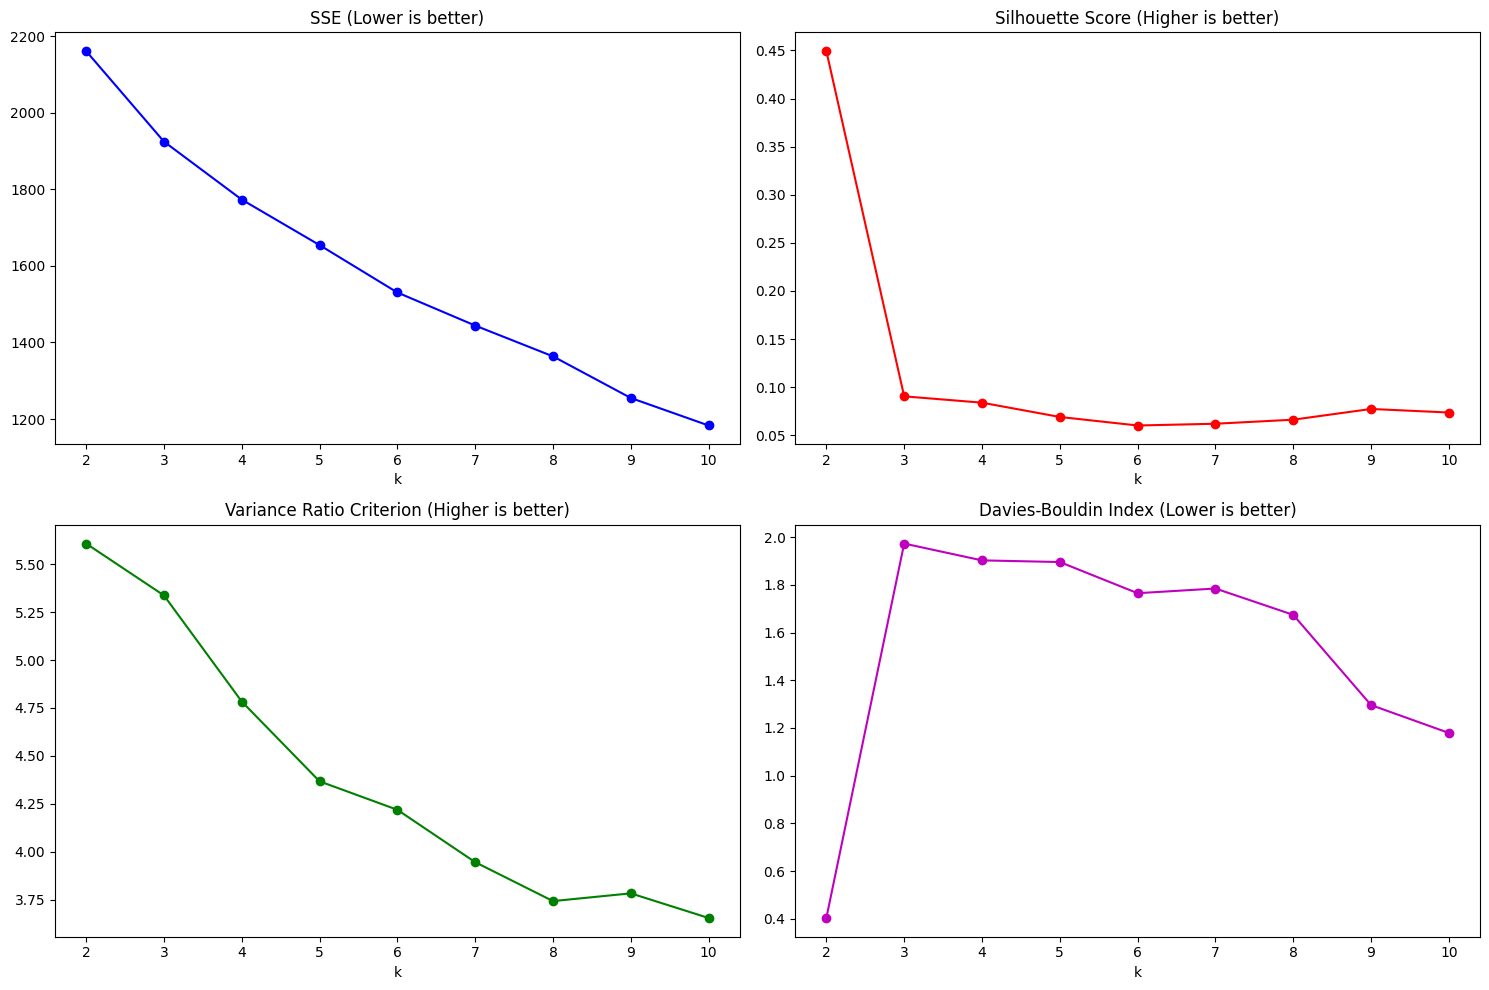

In [67]:
metrics = {
    'sse': [], # Sum of Squared Errors
    'silhouette': [],
    'vrc': [], # Variance Ratio Criterion; Calinski, Harabasz
    'davies_bouldin': []
}
results = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=100)
    labels = kmeans.fit_predict(df)
    results[k] = labels

    metrics['sse'].append(kmeans.inertia_)
    metrics['silhouette'].append(silhouette_score(df.values, labels))
    metrics['vrc'].append(calinski_harabasz_score(df.values, labels))
    metrics['davies_bouldin'].append(davies_bouldin_score(df.values, labels))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
k_range = range(2, 11)

axes[0,0].plot(k_range, metrics['sse'], 'bo-')
axes[0,0].set_title('SSE (Lower is better)')
axes[0,0].set_xlabel('k')

axes[0,1].plot(k_range, metrics['silhouette'], 'ro-')
axes[0,1].set_title('Silhouette Score (Higher is better)')
axes[0,1].set_xlabel('k')

axes[1,0].plot(k_range, metrics['vrc'], 'go-')
axes[1,0].set_title('Variance Ratio Criterion (Higher is better)')
axes[1,0].set_xlabel('k')

axes[1,1].plot(k_range, metrics['davies_bouldin'], 'mo-')
axes[1,1].set_title('Davies-Bouldin Index (Lower is better)')
axes[1,1].set_xlabel('k')

plt.tight_layout()
plt.show()

## Clustering Evaluation
The same evaluation procedure is used again: Overview table, feature importances and a PCA plot.

In [68]:
def cluster_overview(
    original_df: pd.DataFrame,
    cluster_labels: np.ndarray,
    num_cols: List[str],
    cat_cols: List[str],
    bool_cols: List[str],
    feature_importances: Dict[str, float],
) -> pd.DataFrame:
    def num_agg(series):
        res = f"~{series.mean():.2f}"
        if res == "~-0.0":
            return "~0.0"
        return res

    def cat_agg(series):
        vc = series.value_counts(normalize=True)
        if len(vc) >= 1:
            return f"{vc.index[0]} ({vc.iloc[0]:.0%})"
        else:
            return "NA (100%)"

    def bool_agg(series):
        vc = series.value_counts(normalize=True)
        if len(vc) == 1:
            return f"{vc.iloc[0]:.0%} {vc.index[0]}"
        elif len(vc) == 2:
            return f"{vc.iloc[0]:.0%} {vc.index[0]}/{vc.iloc[1]:.0%} {vc.index[1]}"
        else:
            return "100% NA"

    df = original_df.copy(deep=True)
    df["Cluster ID"] = cluster_labels

    # Calculate per-cluster aggregations
    df_clusters = pd.concat(
        [
            df[num_cols + ["Cluster ID"]].groupby("Cluster ID").agg(num_agg) if num_cols else pd.DataFrame(),
            df[cat_cols + ["Cluster ID"]].groupby("Cluster ID").agg(cat_agg) if cat_cols else pd.DataFrame(),
            df[bool_cols + ["Cluster ID"]].groupby("Cluster ID").agg(bool_agg) if bool_cols else pd.DataFrame(),
        ],
        axis=1,
    )
    df_clusters = df_clusters.reset_index()

    # Calculate overall aggregations for entire dataset
    df_overall = pd.concat(
        [
            df[num_cols].agg(num_agg).to_frame().T if num_cols else pd.DataFrame(),
            df[cat_cols].agg(cat_agg).to_frame().T if cat_cols else pd.DataFrame(),
            df[bool_cols].agg(bool_agg).to_frame().T if bool_cols else pd.DataFrame(),
        ],
        axis=1,
    )
    df_overall["Cluster ID"] = "All Clusters"

    # Add member counts
    counts = np.bincount(cluster_labels)
    df_clusters["Members"] = df_clusters.apply(lambda row: counts[int(row["Cluster ID"])], axis=1)
    df_overall["Members"] = len(cluster_labels)

    # Format cluster IDs
    df_clusters["Cluster ID"] = df_clusters["Cluster ID"].apply(lambda x: f"Cluster {x}")

    # Combine cluster data with overall data
    df_result = pd.concat([df_clusters, df_overall], ignore_index=True)

    # Order features by importance
    # Add features not in this dict at the end
    importance_order = list(feature_importances.keys())
    remaining_cols = [col for col in df_result.columns if col not in importance_order and col not in ["Cluster ID", "Members"]]
    df_result = df_result[["Cluster ID", "Members"] + importance_order + remaining_cols]

    return df_result


def feature_importances(
    df: pd.DataFrame,
    labels: np.ndarray
) -> Dict[str, float]:
    classifier = RandomForestClassifier(n_estimators=100)
    classifier.fit(df, labels)
    return dict(
        sorted(
            zip(df.columns, classifier.feature_importances_),
            key=lambda it: it[1],
            reverse=True,
        )
    )



chosen_k = 2
labels = results[chosen_k]

feature_importances_dict = feature_importances(df, labels)
overview_df = cluster_overview(og_df, labels, list(df.columns), [], [], feature_importances_dict)

from IPython.display import display
pd.options.display.max_columns = None
display(overview_df)

,Cluster ID,Members,mfcc_mean_06,mfcc_mean_11,mfcc_mean_04,duration,n_beats,mfcc_mean_01,mfcc_mean_02,mfcc_mean_12,mfcc_std_09,mfcc_mean_03,mfcc_mean_07,mfcc_std_06,mfcc_std_07,mfcc_std_12,chroma_std_05,mfcc_mean_05,mfcc_mean_08,mfcc_mean_09,mfcc_mean_10,mfcc_mean_13,mfcc_std_04,mfcc_std_10,mfcc_std_13,chroma_std_00,chroma_std_01,chroma_std_04,chroma_std_06,chroma_std_10,chroma_entropy,onset_p95,tempo,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_05,mfcc_std_08,mfcc_std_11,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_02,chroma_mean_03,chroma_mean_04,chroma_mean_05,chroma_mean_06,chroma_mean_07,chroma_mean_08,chroma_mean_09,chroma_mean_10,chroma_mean_11,chroma_std_02,chroma_std_03,chroma_std_07,chroma_std_08,chroma_std_09,chroma_std_11,chroma_max_frac,onset_mean,onset_std,onset_peakiness,onset_diff_mean,onset_diff_p95
0,Cluster 0,39,~11.04,~-1.53,~19.16,~211.68,~424.46,~-48.42,~82.53,~4.88,~7.21,~4.01,~-1.18,~8.78,~8.24,~6.13,~0.19,~7.34,~5.60,~-1.48,~4.21,~-0.44,~12.85,~6.86,~5.65,~0.21,~0.17,~0.20,~0.18,~0.20,~2.47,~1.61,~122.76,~58.51,~20.37,~17.42,~11.65,~7.58,~6.90,~422.65,~0.43,~0.37,~0.37,~0.38,~0.40,~0.38,~0.36,~0.37,~0.39,~0.44,~0.44,~0.44,~0.19,~0.19,~0.19,~0.19,~0.21,~0.20,~0.11,~1.10,~0.30,~1.46,~0.26,~0.69
1,Cluster 1,1,~-41.59,~3.57,~-15.78,~53.96,~96.00,~-171.76,~193.51,~-0.90,~4.17,~-120.92,~9.92,~4.71,~3.12,~2.88,~0.12,~-8.10,~-8.54,~-15.88,~18.13,~17.28,~7.16,~4.34,~2.87,~0.11,~0.11,~0.11,~0.12,~0.13,~2.48,~1.27,~107.67,~35.42,~16.33,~14.90,~7.63,~4.85,~4.92,~152.71,~0.49,~0.48,~0.51,~0.48,~0.45,~0.50,~0.47,~0.49,~0.53,~0.61,~0.55,~0.48,~0.13,~0.12,~0.14,~0.14,~0.14,~0.10,~0.10,~0.94,~0.23,~1.35,~0.25,~0.54
2,All Clusters,40,~9.73,~-1.41,~18.28,~207.74,~416.25,~-51.50,~85.31,~4.73,~7.13,~0.89,~-0.90,~8.67,~8.11,~6.05,~0.19,~6.95,~5.24,~-1.84,~4.56,~0.01,~12.71,~6.79,~5.59,~0.21,~0.17,~0.20,~0.18,~0.20,~2.47,~1.60,~122.38,~57.93,~20.27,~17.36,~11.55,~7.51,~6.85,~415.90,~0.43,~0.37,~0.38,~0.38,~0.41,~0.38,~0.36,~0.38,~0.39,~0.44,~0.44,~0.44,~0.19,~0.18,~0.18,~0.19,~0.21,~0.20,~0.11,~1.10,~0.29,~1.45,~0.26,~0.68


In [69]:
print(overview_df.iloc[:, :8].to_latex(index=False))

\begin{tabular}{lrllllll}
\toprule
Cluster ID & Members & mfcc_mean_06 & mfcc_mean_11 & mfcc_mean_04 & duration & n_beats & mfcc_mean_01 \\
\midrule
Cluster 0 & 39 & ~11.04 & ~-1.53 & ~19.16 & ~211.68 & ~424.46 & ~-48.42 \\
Cluster 1 & 1 & ~-41.59 & ~3.57 & ~-15.78 & ~53.96 & ~96.00 & ~-171.76 \\
All Clusters & 40 & ~9.73 & ~-1.41 & ~18.28 & ~207.74 & ~416.25 & ~-51.50 \\
\bottomrule
\end{tabular}



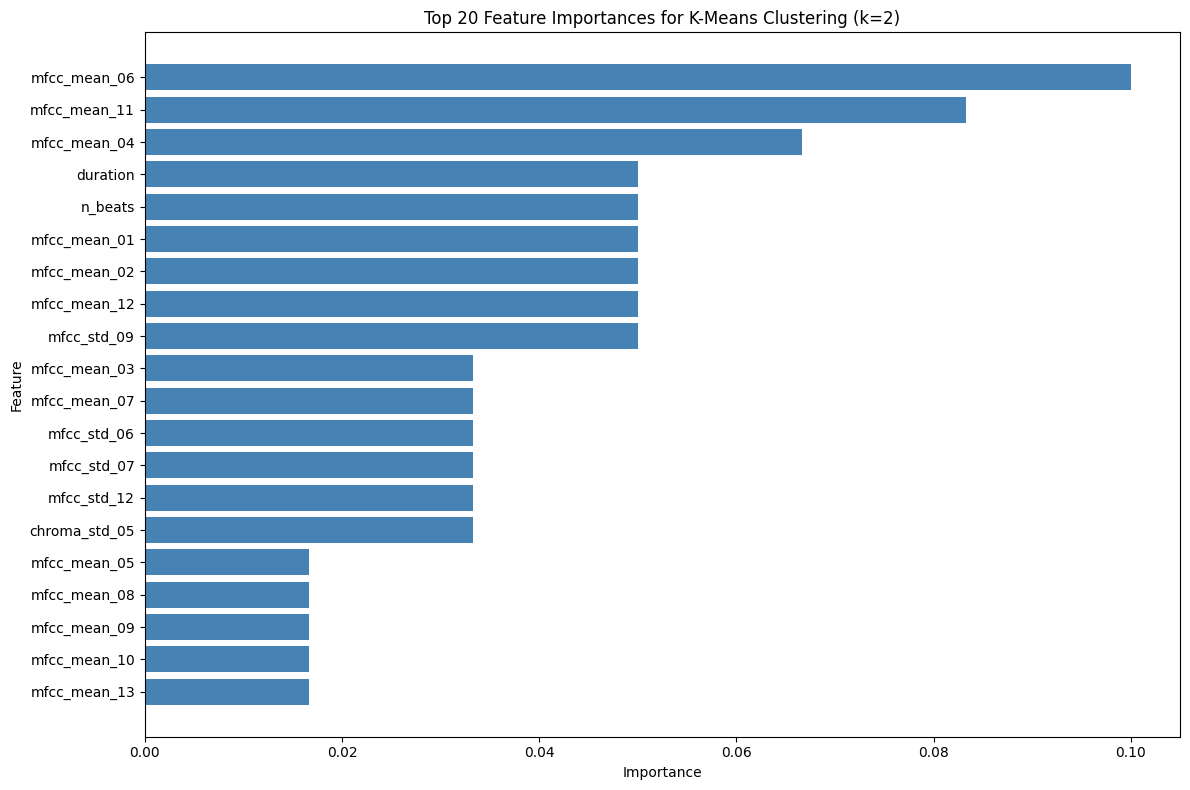

In [70]:
top_n = 20
top_features = list(feature_importances_dict.items())[:top_n]
features, importances = zip(*top_features)

plt.figure(figsize=(12, 8))
plt.barh(range(len(features)), importances, color='steelblue')
plt.yticks(range(len(features)), features)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances for K-Means Clustering (k={chosen_k})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

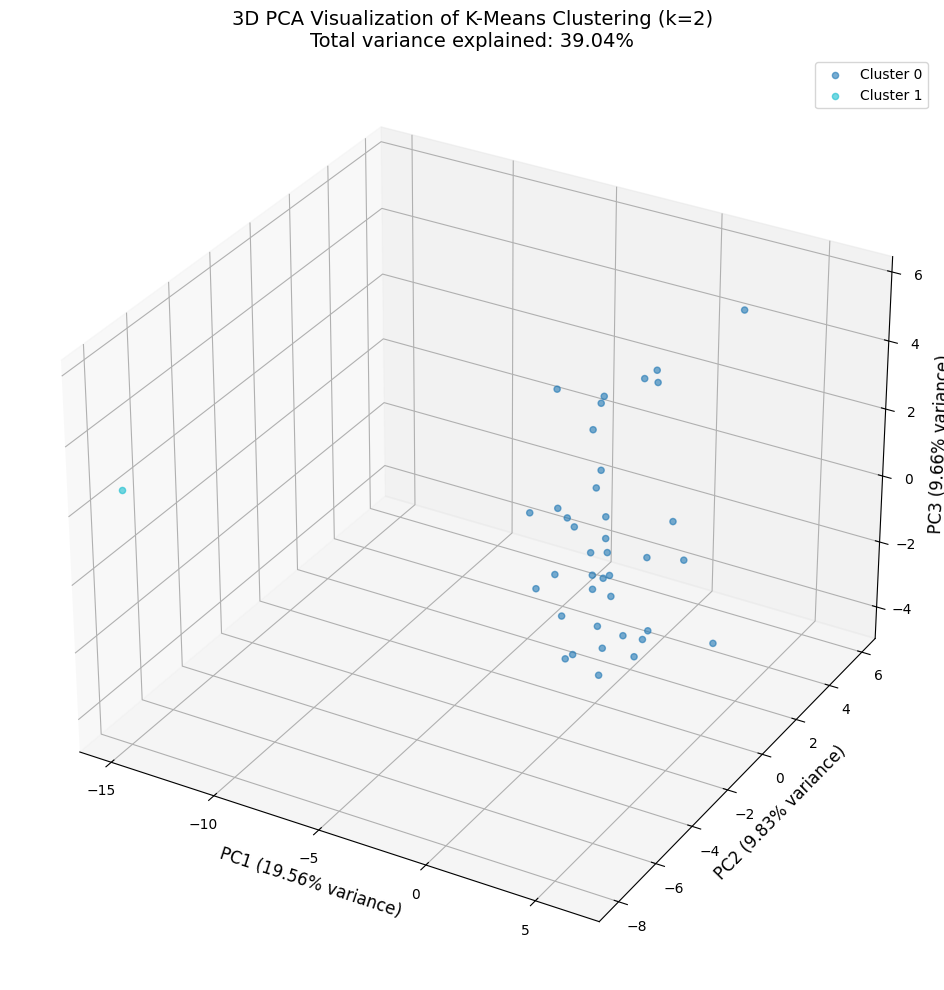

Explained variance by component: [0.1955687  0.09828504 0.09655148]
Total explained variance: 39.04%


In [71]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
pca_features = pca.fit_transform(df)

# Create 3D scatter plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Define colors for each cluster
colors = plt.cm.tab10(np.linspace(0, 1, chosen_k))

# Plot each cluster with a different color
for cluster_id in range(chosen_k):
    cluster_mask = labels == cluster_id
    ax.scatter(
        pca_features[cluster_mask, 0],
        pca_features[cluster_mask, 1],
        pca_features[cluster_mask, 2],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=20
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)', fontsize=12)
ax.set_title(f'3D PCA Visualization of K-Means Clustering (k={chosen_k})\nTotal variance explained: {pca.explained_variance_ratio_.sum():.2%}', fontsize=14)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")

## Motif Extraction
We extract motifs from each songs. This works best on 1D time series, so we transform a chosen feature to a 1D time series (e.g. combine chroma entropy).

In [72]:
def chroma_to_1d(out, mode="entropy"):
    C = out["chroma_bs"]  # (T, 12)
    eps = 1e-9

    if mode == "rms":
        return np.sqrt(np.mean(C**2, axis=1))
    elif mode == "entropy":
        P = C / (C.sum(axis=1, keepdims=True) + eps)
        return -(P * np.log(P + eps)).sum(axis=1)
    elif mode == "max_frac":
        P = C / (C.sum(axis=1, keepdims=True) + eps)
        return P.max(axis=1)
    else:
        raise ValueError("mode must be: 'entropy', 'rms', 'max_frac'")

def normalize(x):
    x = np.asarray(x, float)
    mu = np.mean(x)
    sd = np.std(x) + 1e-9
    return (x - mu) / sd

def find_song_motifs_1d(x, m=32, top_k=3, exclusion_zone=None):
    x = np.asarray(x, float)
    if len(x) < 2 * m:
        return []

    xz = normalize(x)

    # exclusion_zone default: m//2 is typical
    if exclusion_zone is None:
        exclusion_zone = m // 2

    mp = stumpy.stump(xz, m=m, ignore_trivial=True)
    profile = mp[:, 0]     # distance to nearest neighbor
    nn_idx = mp[:, 1].astype(int)

    # candidate motifs are small profile values
    order = np.argsort(profile)
    motifs = []
    used = np.zeros_like(profile, dtype=bool)

    def mark_zone(i):
        a = max(0, i - exclusion_zone)
        b = min(len(used), i + exclusion_zone + 1)
        used[a:b] = True

    for i in order:
        if len(motifs) >= top_k:
            break
        j = nn_idx[i]
        if j < 0:
            continue
        if used[i] or used[j]:
            continue

        motifs.append((int(i), int(j), float(profile[i])))
        mark_zone(i)
        mark_zone(j)

    return motifs

signal_mode = "entropy"  # "entropy" tends to highlight repeated structured sections
m = 32                   # motif length in beats (try 16/32/64 depending on dataset)

# collect motifs per cluster
cluster_motif_rows = []

for idx, row in df.reset_index(drop=True).iterrows():
    c = labels[idx]
    out = audio_features[idx]

    x = chroma_to_1d(out, mode=signal_mode)
    motifs = find_song_motifs_1d(x, m=m, top_k=3)

    for (a, b, dist) in motifs:
        # map beat indices to seconds if beat_times exist
        bt = out.get("beat_times", None)
        if bt is not None and len(bt) > max(a, b):
            a_t = float(bt[a])
            b_t = float(bt[b])
        else:
            a_t = np.nan
            b_t = np.nan

        cluster_motif_rows.append(
            {
                "cluster": c,
                "song_idx": idx,
                "motif_len_beats": m,
                "start_a_beat": a,
                "start_b_beat": b,
                "start_a_sec": a_t,
                "start_b_sec": b_t,
                "motif_dist": dist,
            }
        )

motif_df = pd.DataFrame(cluster_motif_rows)
print(motif_df.shape)
motif_df.head()

(118, 8)


,cluster,song_idx,motif_len_beats,start_a_beat,start_b_beat,start_a_sec,start_b_sec,motif_dist
0,0,0,32,26,114,18.808163,78.808526,3.312511
1,0,0,32,1,82,1.787937,56.865669,5.345552
2,0,0,32,52,131,36.524989,90.395283,5.425803
3,0,1,32,81,179,42.353197,90.534603,2.579535
4,0,1,32,210,121,105.790113,62.020499,3.851709


### Motifs per Cluster
Create a table summarizing statistics about the motifs per cluster.

In [73]:
cluster_summary = (
    motif_df.sort_values("motif_dist")
    .groupby(["cluster", "song_idx"], as_index=False)
    .first()
    .groupby("cluster")
    .agg(
        songs_in_cluster=("song_idx", "nunique"),
        mean_best_motif_dist=("motif_dist", "mean"),
        median_best_motif_dist=("motif_dist", "median"),
    )
    .sort_values("mean_best_motif_dist")
)

cluster_summary

,songs_in_cluster,mean_best_motif_dist,median_best_motif_dist
cluster,,,
0,39,2.074594,1.943587
1,1,4.173123,4.173123


Boxplot of the best motif per cluster, measured by distance.

/tmp/ipython-input-434951430.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=boxplot_labels, showfliers=False)


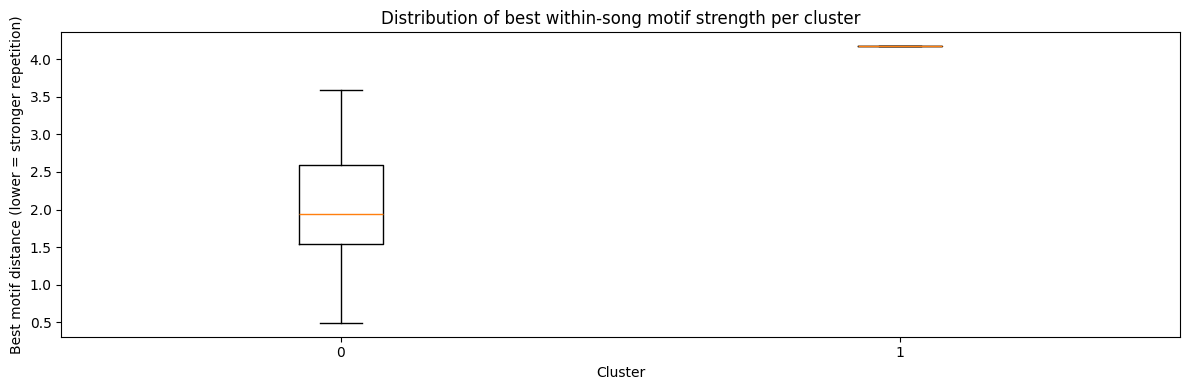

In [74]:
best_per_song = (
    motif_df.sort_values("motif_dist")
    .groupby(["cluster", "song_idx"], as_index=False)
    .first()
)

plt.figure(figsize=(12, 4))

data = [
    best_per_song.loc[best_per_song["cluster"] == c, "motif_dist"].values
    for c in sorted(best_per_song["cluster"].unique())
]
boxplot_labels = [str(c) for c in sorted(best_per_song["cluster"].unique())]

plt.boxplot(data, labels=boxplot_labels, showfliers=False)
plt.xlabel("Cluster")
plt.ylabel("Best motif distance (lower = stronger repetition)")
plt.title("Distribution of best within-song motif strength per cluster")
plt.tight_layout()
plt.show()

## Anomaly Detection
Since we already have clusters, we can use the previous cluster centers to detect anomalies in the data. We define an anomaly as a data point deviates from the typical pattern of the cluster.

First, let us resample the datapoints to a fixed time interval. This makes visualization possible.

In [75]:
def resample_ts(X, T=256):
    X = np.asarray(X, float)
    L, d = X.shape
    if L == T:
        return X
    if L < 2:
        return np.repeat(X, T, axis=0)

    old = np.linspace(0, 1, L)
    new = np.linspace(0, 1, T)
    Y = np.zeros((T, d), dtype=float)
    for j in range(d):
        Y[:, j] = np.interp(new, old, X[:, j])
    return Y

def per_song_normalize(X):
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + 1e-9
    return (X - mu) / sd

T = 128
d_keep = 13  # first 13 MFCCs

X_ts = []
y = [] # artist, used later for shaplets

for out in audio_features:
    X = out["mfcc_bs"][:, :d_keep]         # (n_beats, d_keep)
    X = resample_ts(X, T=T)                # (T, d_keep)
    X = per_song_normalize(X)                  # normalize per song
    X_ts.append(X)
    y.append(out["artist"])

y = np.array(y)
print(y.shape)
X_ts = np.stack(X_ts, axis=0)              # (n_songs, T, d_keep)
X_ts.shape

(40,)


(40, 128, 13)

Now compute anomalies by simpy using euclidean distance between the timeseries and the cluster average

In [76]:
unique_clusters = np.sort(np.unique(labels))

# average centers
cluster_mu = {}
for c in unique_clusters:
    idx = np.where(labels == c)[0]
    cluster_mu[c] = X_ts[idx].mean(axis=0) # (T, d)

# calculate distances
scores = np.zeros((len(df), T), dtype=float)
for i in range(len(df)):
    c = labels[i]
    diff = X_ts[i] - cluster_mu[c] # (T, d)
    scores[i] = np.linalg.norm(diff, axis=1)

# normalize scores
med = np.median(scores)
mad = np.median(np.abs(scores - med)) + 1e-9
scores_z = (scores - med) / mad
scores_z.shape

(40, 128)

Now we have essentially an anomaly score at each point t in the timeseries. We can visualize the anomly level using heatmaps for each cluster.

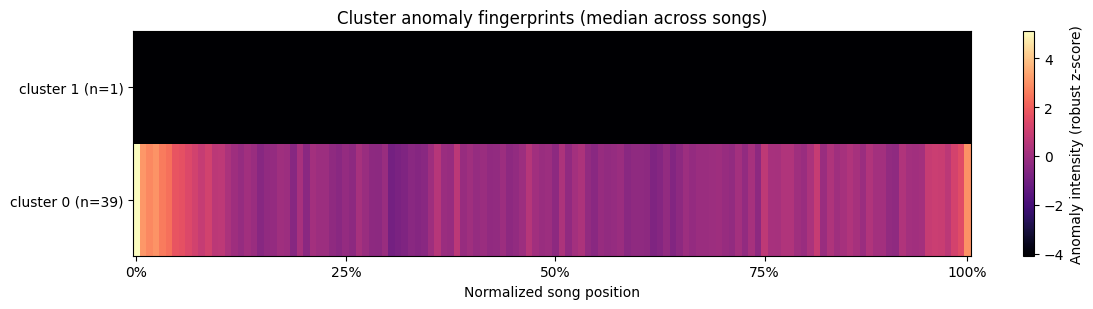

In [77]:
# Aggregate per cluster: median anomaly score at each time t
cluster_fingerprint = []
cluster_sizes = []

for c in unique_clusters:
    idx = np.where(labels == c)[0]
    cluster_sizes.append(len(idx))
    cluster_fingerprint.append(np.median(scores_z[idx], axis=0))

cluster_fingerprint = np.vstack(cluster_fingerprint)  # (n_clusters, T)

plt.figure(figsize=(12, 0.6 * len(unique_clusters) + 2))
plt.imshow(cluster_fingerprint, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Anomaly intensity (robust z-score)")
plt.yticks(
    np.arange(len(unique_clusters)),
    [f"cluster {c} (n={n})" for c, n in zip(unique_clusters, cluster_sizes)],
)
plt.xticks(
    [0, T // 4, T // 2, 3 * T // 4, T - 1],
    ["0%", "25%", "50%", "75%", "100%"],
)
plt.xlabel("Normalized song position")
plt.title("Cluster anomaly fingerprints (median across songs)")
plt.tight_layout()
plt.show()

## Shaplets
For shaplets we can re-use the sampled timeseries we just created for the anomalies. We resample again to reduce training time.

In [78]:
T = 32 # aggressively reduce sample length
d_keep = 13  # first 13 MFCCs

X_ts = []
y = [] # artist, used later for shaplets

for out in audio_features:
    X = out["mfcc_bs"][:, :d_keep]         # (n_beats, d_keep)
    X = resample_ts(X, T=T)                # (T, d_keep)
    X = per_song_normalize(X)              # normalize per song
    X_ts.append(X)
    y.append(out["artist"])

y = np.array(y)
print(y.shape)
X_ts = np.stack(X_ts, axis=0)              # (n_songs, T, d_keep)
print(X_ts.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_ts, y, test_size=0.2, stratify=y
)

shapelet_sizes = {16: 2, 32: 1}

clf = LearningShapelets(
    n_shapelets_per_size=shapelet_sizes,
    optimizer="adam",
    batch_size=64,
    weight_regularizer=1e-3,
    max_iter=50,
    verbose=1,
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["ART07024718", "ART25707984"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

(40,)
(40, 32, 13)


/usr/local/lib/python3.12/dist-packages/tslearn/shapelets/shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 3.0741 - loss: 3.0772
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 3.0506 - loss: 3.0537
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 3.0272 - loss: 3.0303
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 3.0037 - loss: 3.0068
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.9803 - loss: 2.9834
Epoch 6/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.9569 - loss: 2.9600
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.9335 - loss: 2.9366
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.9101 - loss: 2.9132
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.8868 - loss: 2.8899
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.8635 - loss: 2.8666
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.8403 - loss: 2.8433
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.8170 - loss: 2.8201
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - binary_accuracy: 0.5000 - binary_crossentropy: 2.7938 - loss: 2.7969
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/st

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/li

Plot the learned shapelets. Here we only plot a few shapelets to show examples.

Num shapelets: 3
Example shapelet shape: (16, 13)


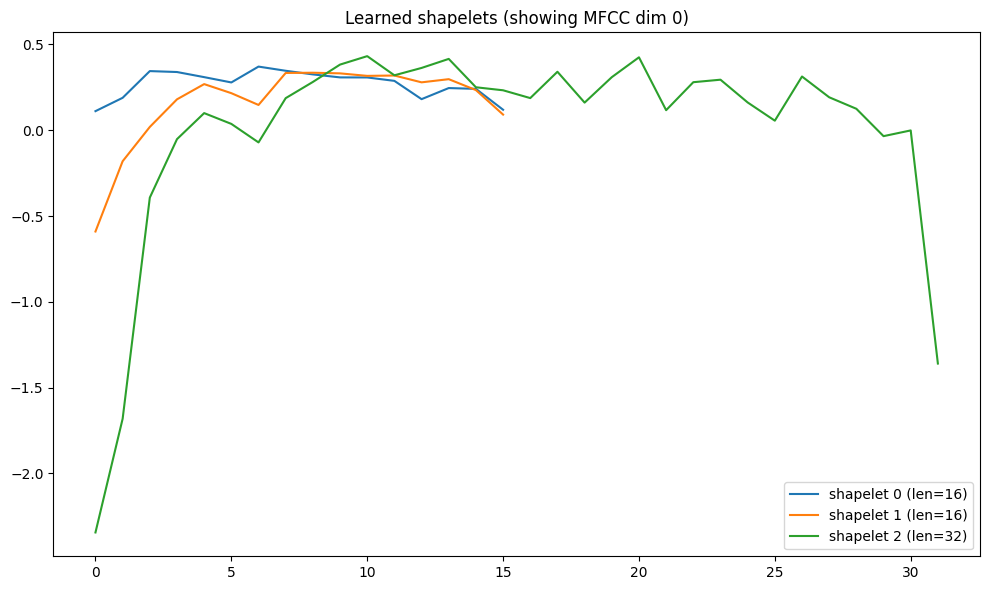

In [79]:
shapelets = clf.shapelets_

print("Num shapelets:", len(shapelets))
print("Example shapelet shape:", shapelets[0].shape)

# plot a few shapelets (overlay dimensions or pick one MFCC dim)
n_plot = min(6, len(shapelets))
mfcc_dim = 0  # plot MFCC-1 by default

plt.figure(figsize=(10, 6))
for i in range(n_plot):
    s = shapelets[i][:, mfcc_dim]
    plt.plot(s, label=f"shapelet {i} (len={shapelets[i].shape[0]})")
plt.title(f"Learned shapelets (showing MFCC dim {mfcc_dim})")
plt.legend()
plt.tight_layout()
plt.show()

Match the shaplet back to the most probable location in the songs.

In [80]:
def match_all_shapelets(X_ts, shapelets, top_k_songs=10):
    rows = []
    for sh_id, sh in enumerate(shapelets):
        for song_idx in range(len(X_ts)):
            start, dist = best_match_location(X_ts[song_idx], sh)
            rows.append(
                {
                    "shapelet_id": sh_id,
                    "shapelet_len": sh.shape[0],
                    "song_idx": song_idx,
                    "start_T": start,
                    "dist": dist,
                    "artist": audio_features[song_idx]["artist"],
                }
            )

    dfm = pd.DataFrame(rows)

    # for each shapelet, keep only the top-k closest songs (best matches)
    df_top = (
        dfm.sort_values(["shapelet_id", "dist"], ascending=[True, True])
        .groupby("shapelet_id")
        .head(top_k_songs)
        .reset_index(drop=True)
    )
    return dfm, df_top


df_all_matches, df_top_matches = match_all_shapelets(
    X_ts=X_ts, shapelets=shapelets, top_k_songs=10
)

df_top_matches.head(20)

,shapelet_id,shapelet_len,song_idx,start_T,dist,artist
0,0,16,30,2,7.537878,ART25707984
1,0,16,28,14,8.198835,ART25707984
2,0,16,5,12,9.212734,ART07024718
3,0,16,2,2,9.402894,ART07024718
4,0,16,32,15,10.032471,ART25707984
5,0,16,22,8,10.118402,ART25707984
6,0,16,12,8,10.265694,ART07024718
7,0,16,1,8,10.379725,ART07024718
8,0,16,27,13,10.393692,ART25707984
9,0,16,29,5,10.667390,ART25707984


Which artist prefers which shaplet?




In [81]:
summary = (
    df_top_matches.groupby(["shapelet_id", "shapelet_len", "artist"])
    .size()
    .unstack(fill_value=0)
)

# Add a simple dominance score: fraction of top matches belonging to the majority artist
summary["dominance"] = summary.max(axis=1) / summary.sum(axis=1)
summary.sort_values("dominance", ascending=False).head(15)

,artist,ART07024718,ART25707984,dominance
shapelet_id,shapelet_len,,,
0,16,4,6,0.6
1,16,4,6,0.6
2,32,6,4,0.6
